# Zomato Bangalore Restaurant Data Analysis

**Author:** Poojan Javiya  
**Project Type:** Data Cleaning & Visualization Internship Task

## Loading the Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("himanshupoddar/zomato-bangalore-restaurants")

print("Path to dataset files:", path)

Path to dataset files: /home/poojan/.cache/kagglehub/datasets/himanshupoddar/zomato-bangalore-restaurants/versions/1


In [3]:
import os 

print(os.listdir(path))

['zomato.csv']


## Dataset Overview

In [4]:
import pandas as pd

file_path = path + "/zomato.csv"

df = pd.read_csv(file_path)
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   url                          51717 non-null  str  
 1   address                      51717 non-null  str  
 2   name                         51717 non-null  str  
 3   online_order                 51717 non-null  str  
 4   book_table                   51717 non-null  str  
 5   rate                         43942 non-null  str  
 6   votes                        51717 non-null  int64
 7   phone                        50509 non-null  str  
 8   location                     51696 non-null  str  
 9   rest_type                    51490 non-null  str  
 10  dish_liked                   23639 non-null  str  
 11  cuisines                     51672 non-null  str  
 12  approx_cost(for two people)  51371 non-null  str  
 13  reviews_list                 51717 non-null  str  
 14  m

In [6]:
df.isnull().sum().sort_values(ascending=False)

dish_liked                     28078
rate                            7775
phone                           1208
approx_cost(for two people)      346
rest_type                        227
cuisines                          45
location                          21
url                                0
address                            0
votes                              0
name                               0
online_order                       0
book_table                         0
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['rate'].unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',    'NEW',  '2.9/5',  '3.5/5',      nan,  '2.6/5', '3.8 /5',
  '3.4/5',  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',
  '2.3/5', '3.4 /5',      '-', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5',
 '4.0 /5', '4.1 /5', '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5',
 '3.5 /5', '2.7 /5', '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5',
 '4.4 /5',  '4.9/5',  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5',
 '3.0 /5', '4.8 /5', '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5', '2.2 /5',
 '2.0 /5', '1.8 /5']
Length: 65, dtype: str

## Data Cleaning

In [9]:
import numpy as np

In [10]:
df['rate'] = df['rate'].replace(['NEW', '-'], np.nan)

In [11]:
df['rate'].unique()

<StringArray>
[ '4.1/5',  '3.8/5',  '3.7/5',  '3.6/5',  '4.6/5',  '4.0/5',  '4.2/5',
  '3.9/5',  '3.1/5',  '3.0/5',  '3.2/5',  '3.3/5',  '2.8/5',  '4.4/5',
  '4.3/5',      nan,  '2.9/5',  '3.5/5',  '2.6/5', '3.8 /5',  '3.4/5',
  '4.5/5',  '2.5/5',  '2.7/5',  '4.7/5',  '2.4/5',  '2.2/5',  '2.3/5',
 '3.4 /5', '3.6 /5',  '4.8/5', '3.9 /5', '4.2 /5', '4.0 /5', '4.1 /5',
 '3.7 /5', '3.1 /5', '2.9 /5', '3.3 /5', '2.8 /5', '3.5 /5', '2.7 /5',
 '2.5 /5', '3.2 /5', '2.6 /5', '4.5 /5', '4.3 /5', '4.4 /5',  '4.9/5',
  '2.1/5',  '2.0/5',  '1.8/5', '4.6 /5', '4.9 /5', '3.0 /5', '4.8 /5',
 '2.3 /5', '4.7 /5', '2.4 /5', '2.1 /5', '2.2 /5', '2.0 /5', '1.8 /5']
Length: 63, dtype: str

### Handling Missing Values

In [12]:
df['rate'].isnull().sum()

np.int64(10052)

In [13]:
df['rate'] = df['rate'].str.replace('/5','')
df['rate'] = df['rate'].str.strip()
df['rate'] = pd.to_numeric(df['rate'])

In [14]:
df['rate'].unique()

array([4.1, 3.8, 3.7, 3.6, 4.6, 4. , 4.2, 3.9, 3.1, 3. , 3.2, 3.3, 2.8,
       4.4, 4.3, nan, 2.9, 3.5, 2.6, 3.4, 4.5, 2.5, 2.7, 4.7, 2.4, 2.2,
       2.3, 4.8, 4.9, 2.1, 2. , 1.8])

### Handling Missing Values

In [15]:
df.dropna(subset=['rate'],inplace=True)

In [16]:
df['rate'].isnull().sum()

np.int64(0)

### Removing Unnecessary Columns

In [17]:
dropped_cols = ['url', 'address','phone', 'reviews_list', 'dish_liked']
df = df.drop(columns=dropped_cols)
df

,name,online_order,book_table,rate,votes,location,rest_type,cuisines,approx_cost(for two people),menu_item,listed_in(type),listed_in(city)
0,Jalsa,Yes,Yes,4.1,775,Banashankari,Casual Dining,"North Indian, Mughlai, Chinese",800,[],Buffet,Banashankari
1,Spice Elephant,Yes,No,4.1,787,Banashankari,Casual Dining,"Chinese, North Indian, Thai",800,[],Buffet,Banashankari
2,San Churro Cafe,Yes,No,3.8,918,Banashankari,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,[],Buffet,Banashankari
3,Addhuri Udupi Bhojana,No,No,3.7,88,Banashankari,Quick Bites,"South Indian, North Indian",300,[],Buffet,Banashankari
4,Grand Village,No,No,3.8,166,Basavanagudi,Casual Dining,"North Indian, Rajasthani",600,[],Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...
51709,The Farm House Bar n Grill,No,No,3.7,34,Whitefield,"Casual Dining, Bar","North Indian, Continental",800,[],Pubs and bars,Whitefield
51711,Bhagini,No,No,2.5,81,Whitefield,"Casual Dining, Bar","Andhra, South Indian, Chinese, North Indian",800,[],Pubs and bars,Whitefield
51712,Best Brews - Four Points by Sheraton Bengaluru...,No,No,3.6,27,Whitefield,Bar,Continental,"1,500",[],Pubs and bars,Whitefield
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,No,Yes,4.3,236,"ITPL Main Road, Whitefield",Bar,Finger Food,"2,500",[],Pubs and bars,Whitefield


In [18]:
df['menu_item'].unique()

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [19]:
df.info()

<class 'pandas.DataFrame'>
Index: 41665 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         41665 non-null  str    
 1   online_order                 41665 non-null  str    
 2   book_table                   41665 non-null  str    
 3   rate                         41665 non-null  float64
 4   votes                        41665 non-null  int64  
 5   location                     41665 non-null  str    
 6   rest_type                    41516 non-null  str    
 7   cuisines                     41654 non-null  str    
 8   approx_cost(for two people)  41418 non-null  str    
 9   menu_item                    41665 non-null  str    
 10  listed_in(type)              41665 non-null  str    
 11  listed_in(city)              41665 non-null  str    
dtypes: float64(1), int64(1), str(10)
memory usage: 4.1 MB


In [20]:
df.isnull().sum()

name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
location                         0
rest_type                      149
cuisines                        11
approx_cost(for two people)    247
menu_item                        0
listed_in(type)                  0
listed_in(city)                  0
dtype: int64

In [21]:
na_cols = ['rest_type', 'cuisines', 'approx_cost(for two people)']
df.dropna(subset=na_cols, inplace=True)

In [22]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
location                       0
rest_type                      0
cuisines                       0
approx_cost(for two people)    0
menu_item                      0
listed_in(type)                0
listed_in(city)                0
dtype: int64

In [23]:
df.info()

<class 'pandas.DataFrame'>
Index: 41263 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         41263 non-null  str    
 1   online_order                 41263 non-null  str    
 2   book_table                   41263 non-null  str    
 3   rate                         41263 non-null  float64
 4   votes                        41263 non-null  int64  
 5   location                     41263 non-null  str    
 6   rest_type                    41263 non-null  str    
 7   cuisines                     41263 non-null  str    
 8   approx_cost(for two people)  41263 non-null  str    
 9   menu_item                    41263 non-null  str    
 10  listed_in(type)              41263 non-null  str    
 11  listed_in(city)              41263 non-null  str    
dtypes: float64(1), int64(1), str(10)
memory usage: 4.1 MB


### Cleaning Cost Column

In [24]:
df['approx_cost(for two people)'].unique()[:20]

<StringArray>
[  '800',   '300',   '600',   '700',   '550',   '500',   '450',   '650',
   '400',   '900',   '200',   '750',   '150',   '850',   '100', '1,200',
   '350',   '250',   '950', '1,000']
Length: 20, dtype: str

In [25]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',', '')

In [26]:
df['approx_cost(for two people)'] = pd.to_numeric(df['approx_cost(for two people)'])

In [27]:
df['approx_cost(for two people)'].dtype

dtype('int64')

In [28]:
df.info()

<class 'pandas.DataFrame'>
Index: 41263 entries, 0 to 51716
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         41263 non-null  str    
 1   online_order                 41263 non-null  str    
 2   book_table                   41263 non-null  str    
 3   rate                         41263 non-null  float64
 4   votes                        41263 non-null  int64  
 5   location                     41263 non-null  str    
 6   rest_type                    41263 non-null  str    
 7   cuisines                     41263 non-null  str    
 8   approx_cost(for two people)  41263 non-null  int64  
 9   menu_item                    41263 non-null  str    
 10  listed_in(type)              41263 non-null  str    
 11  listed_in(city)              41263 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 4.1 MB


## Exploratory Data Analysis (EDA)

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

### Rating Distribution

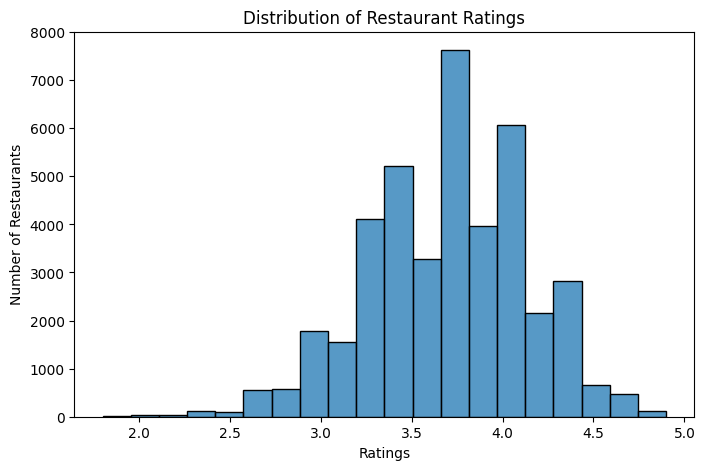

In [30]:
plt.figure(figsize=(8,5))

sns.histplot(df['rate'], bins=20)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Ratings")
plt.ylabel("Number of Restaurants")

plt.show()

### Insight

Most restaurants are concentrated between ratings 3.2 and 4.1, showing that the majority of restaurants maintain moderate to high customer satisfaction. Very low-rated restaurants are relatively uncommon, while extremely high ratings above 4.5 are also rare.

### Online Order vs Ratings

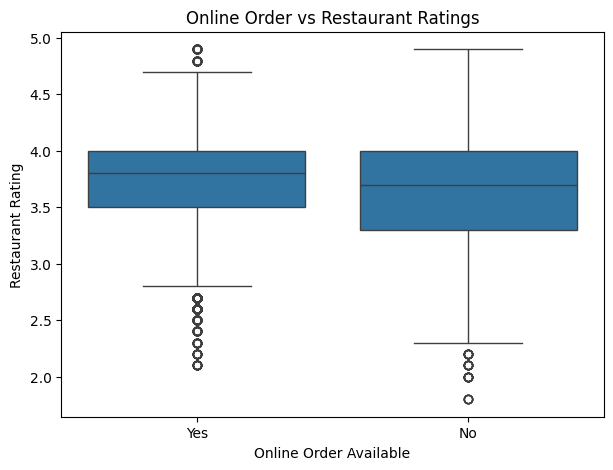

In [31]:
plt.figure(figsize=(7,5))

sns.boxplot(x='online_order', y='rate', data=df)

plt.title("Online Order vs Restaurant Ratings")
plt.xlabel("Online Order Available")
plt.ylabel("Restaurant Rating")

plt.show()

### Insight

Restaurants offering online ordering tend to have slightly higher median ratings compared to restaurants that do not provide online ordering services. However, both categories show a similar overall rating distribution.

### Cost vs Ratings

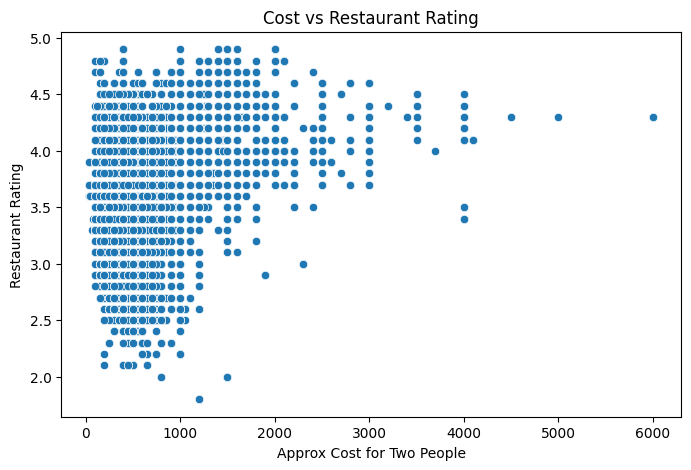

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='approx_cost(for two people)',
    y='rate',
    data=df
)

plt.title("Cost vs Restaurant Rating")
plt.xlabel("Approx Cost for Two People")
plt.ylabel("Restaurant Rating")

plt.show()

### Insight

Restaurant cost and ratings show only a weak positive relationship. Many moderately priced restaurants achieve high ratings, indicating that expensive restaurants are not necessarily rated significantly better by customers.

In [33]:
df['rest_type'].value_counts().head(10)

rest_type
Quick Bites           13885
Casual Dining          9614
Cafe                   3369
Dessert Parlor         1850
Delivery               1667
Takeaway, Delivery     1279
Casual Dining, Bar     1092
Bakery                  704
Beverage Shop           640
Bar                     640
Name: count, dtype: int64

### Top Restaurant Types

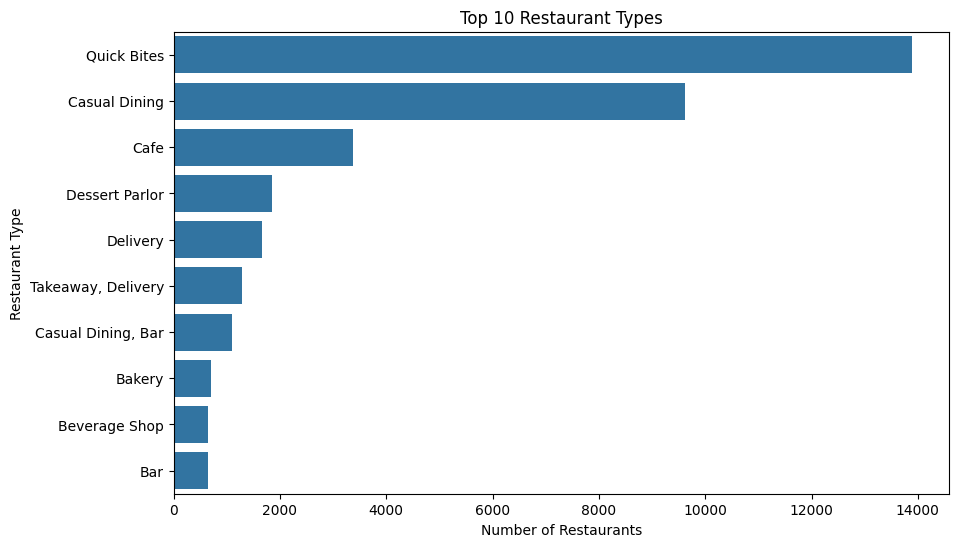

In [34]:
plt.figure(figsize=(10,6))

top_types = df['rest_type'].value_counts().head(10)

sns.barplot(
    x=top_types.values,
    y=top_types.index
)

plt.title("Top 10 Restaurant Types")
plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Type")

plt.show()

### Insight

Quick Bites and Casual Dining restaurants dominate the Bangalore restaurant market, indicating strong demand for affordable and convenient dining experiences.

In [35]:
df.to_csv("cleaned_zomato.csv", index=False)

## Conclusion

The dataset required significant preprocessing due to inconsistent formatting, missing values, and mixed data types. After cleaning, exploratory analysis revealed that most Bangalore restaurants maintain ratings between 3.5 and 4.1. Restaurant cost showed only a weak relationship with ratings, while online ordering was associated with slightly higher customer ratings.